---
---
## Parte 03 - Comparação (Modelo A vs Modelo B) e Recomendação

---
---

Esta Etapa foi desenvolvida em três partes:

1. Métricas Globais: 
2. O bootstrap pareado estratificado complementa o teste porque o McNemar avalia principalmente a diferença de acurácia. Como o problema é desbalanceado, também precisamos ver métricas menos dominadas pelas classes majoritárias, como **Acurácia Balanceada** e **F1 macro**. A estratificação por categoria_real preserva a composição da base original.
3. Uso do teste McNemar, pois os modelos foram avaliados nos mesmos 5.000 chamados. Isso elimina a hipótese de usar um teste para amostras independentes. A pergunta estatística a ser respondida é se há assimetria entre dois tipos de discordância: casos em que A acerta e B erra contra casos em que A erra e B acerta.

Iremos tomar uma das três decisões:

- Trocar pelo Modelo B, se ele melhora globalmente e não piora categorias críticas.
- Não trocar, se o ganho global não for estatisticamente claro ou se B piorar métricas centrais.
- Fazer piloto controlado, se B melhora globalmente, mas apresenta trade-offs por categoria. Nesse caso, a troca deve vir com monitoramento, revisão manual nos grupos frágeis e plano de rollback.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
from IPython.display import display
from functions import pretty_label, save_figure, save_table, load_and_prepare_data, calcular_metricas_globais, gerar_amostra_bootstrap_estratificada
warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

output_dir = Path("../results")
fig_dir = output_dir / "figures/auditoria_modelo_a"
tab_dir = output_dir / "tables"
fig_dir.mkdir(parents=True, exist_ok=True)
tab_dir.mkdir(parents=True, exist_ok=True)

In [3]:
path = Path("../dados/chamados_com_predicoes.csv")
df = load_and_prepare_data(path)

n_bootstrap = 1000
seed = 42
alpha = 0.05

In [10]:
df["pred_modelo_a"] = df["pred_modelo_a"].astype(str).str.strip()
df["pred_modelo_b"] = df["pred_modelo_b"].astype(str).str.strip()
df["faixa_tamanho_texto"] = pd.qcut(
    df["palavra_count"],q=4,
    labels=["Textos mais curtos",
            "Textos médio-curtos",
            "Textos médio-longos",
            "Textos mais longos"],
    duplicates="drop")
classes = (df["categoria_real"].value_counts().sort_values(ascending=False).index.tolist())

df_comp = df.copy()
df_comp["acerto_modelo_a"] = df_comp["categoria_real"] == df_comp["pred_modelo_a"]
df_comp["acerto_modelo_b"] = df_comp["categoria_real"] == df_comp["pred_modelo_b"]

df_comp["ambos_acertam"] = df_comp["acerto_modelo_a"] & df_comp["acerto_modelo_b"]
df_comp["ambos_erram"] = ~df_comp["acerto_modelo_a"] & ~df_comp["acerto_modelo_b"]
df_comp["a_acerta_b_erra"] = df_comp["acerto_modelo_a"] & ~df_comp["acerto_modelo_b"]
df_comp["b_acerta_a_erra"] = ~df_comp["acerto_modelo_a"] & df_comp["acerto_modelo_b"]

In [11]:
def executar_mcnemar(acerto_a, acerto_b):
    ambos_acertam = int((acerto_a & acerto_b).sum())
    ambos_erram = int((~acerto_a & ~acerto_b).sum())
    a_acerta_b_erra = int((acerto_a & ~acerto_b).sum())
    b_acerta_a_erra = int((~acerto_a & acerto_b).sum())

    tabela = np.array([
        [ambos_acertam, a_acerta_b_erra],
        [b_acerta_a_erra, ambos_erram]
    ])

    n_discordantes = a_acerta_b_erra + b_acerta_a_erra

    if n_discordantes == 0:
        return {
            "ambos_acertam": ambos_acertam,
            "ambos_erram": ambos_erram,
            "a_acerta_b_erra": a_acerta_b_erra,
            "b_acerta_a_erra": b_acerta_a_erra,
            "n_discordantes": n_discordantes,
            "estatistica": np.nan,
            "p_valor": 1.0,
            "metodo": "Sem casos discordantes",
            "ganho_liquido_b": 0
        }

    usar_exato = n_discordantes <= 50

    resultado = mcnemar(
        tabela,
        exact=usar_exato,
        correction=not usar_exato
    )

    return {
        "ambos_acertam": ambos_acertam,
        "ambos_erram": ambos_erram,
        "a_acerta_b_erra": a_acerta_b_erra,
        "b_acerta_a_erra": b_acerta_a_erra,
        "n_discordantes": n_discordantes,
        "estatistica": resultado.statistic,
        "p_valor": resultado.pvalue,
        "metodo": "McNemar exato" if usar_exato else "McNemar qui-quadrado com correção de continuidade",
        "ganho_liquido_b": b_acerta_a_erra - a_acerta_b_erra
    }


def formatar_ic(valor, inf, sup, casas=3):
    return f"{valor:.{casas}f} [{inf:.{casas}f}, {sup:.{casas}f}]"

In [14]:
def comparar_metricas_globais_bootstrap(df, labels, n_bootstrap=1000, alpha=0.05, seed=42):
    metricas_a = calcular_metricas_globais(
        df["categoria_real"], df["pred_modelo_a"], labels)

    metricas_b = calcular_metricas_globais(
        df["categoria_real"], df["pred_modelo_b"], labels)

    rng = np.random.default_rng(seed)
    resultados_boot = []

    for _ in range(n_bootstrap):
        amostra = gerar_amostra_bootstrap_estratificada(
            df, coluna_estrato="categoria_real", rng=rng)

        boot_a = calcular_metricas_globais(
            amostra["categoria_real"], amostra["pred_modelo_a"], labels)

        boot_b = calcular_metricas_globais(
            amostra["categoria_real"], amostra["pred_modelo_b"], labels)

        for metrica in metricas_a:
            resultados_boot.append({
                "metrica": metrica,
                "delta_b_menos_a": boot_b[metrica] - boot_a[metrica]
            })

    boot = pd.DataFrame(resultados_boot)
    linhas = []

    for metrica in metricas_a:
        dist = boot.loc[boot["metrica"] == metrica, "delta_b_menos_a"]
        linhas.append({
            "Métrica": metrica,
            "Modelo A": metricas_a[metrica],
            "Modelo B": metricas_b[metrica],
            "Δ(B-A)": metricas_b[metrica] - metricas_a[metrica],
            "Δ IC Inf. (95%)": dist.quantile(alpha / 2),
            "Δ IC Sup. (95%)": dist.quantile(1 - alpha / 2),
            "Δ Desvio Bootstrap": dist.std()
        })

    tabela = pd.DataFrame(linhas)
    return tabela, boot

In [15]:
tabela_global_ab, bootstrap_global_ab = comparar_metricas_globais_bootstrap(
    df_comp, labels=classes, n_bootstrap=n_bootstrap, alpha=alpha, seed=seed)

display(tabela_global_ab)
save_table(
    tabela_global_ab,
    tab_dir,
    "07_comparacao_global_modelo_a_vs_b_bootstrap.csv"
)

,Métrica,Modelo A,Modelo B,Δ(B-A),Δ IC Inf. (95%),Δ IC Sup. (95%),Δ Desvio Bootstrap
0,Acurácia,0.772800,0.867600,0.094800,0.080795,0.109605,0.007232
1,Acurácia Balanceada,0.770992,0.852288,0.081296,0.064014,0.099624,0.008564
2,Precisão Macro,0.774338,0.859602,0.085264,0.068349,0.101792,0.008540
3,Recall Macro,0.770992,0.852288,0.081296,0.064014,0.099624,0.008564
4,F1 Macro,0.770438,0.851562,0.081124,0.064769,0.097810,0.008306
5,Precisão Ponderada,0.777637,0.866086,0.088449,0.073711,0.103423,0.007361
6,Recall Ponderada,0.772800,0.867600,0.094800,0.080795,0.109605,0.007232
7,F1 Ponderada,0.772524,0.863572,0.091048,0.076800,0.105771,0.007378
8,Kappa de Cohen,0.732224,0.843693,0.111469,0.094769,0.128991,0.008540
9,Coeficiente de Matthews,0.733362,0.844336,0.110974,0.094345,0.128358,0.008507


PosixPath('../results/tables/07_comparacao_global_modelo_a_vs_b_bootstrap.csv.csv')

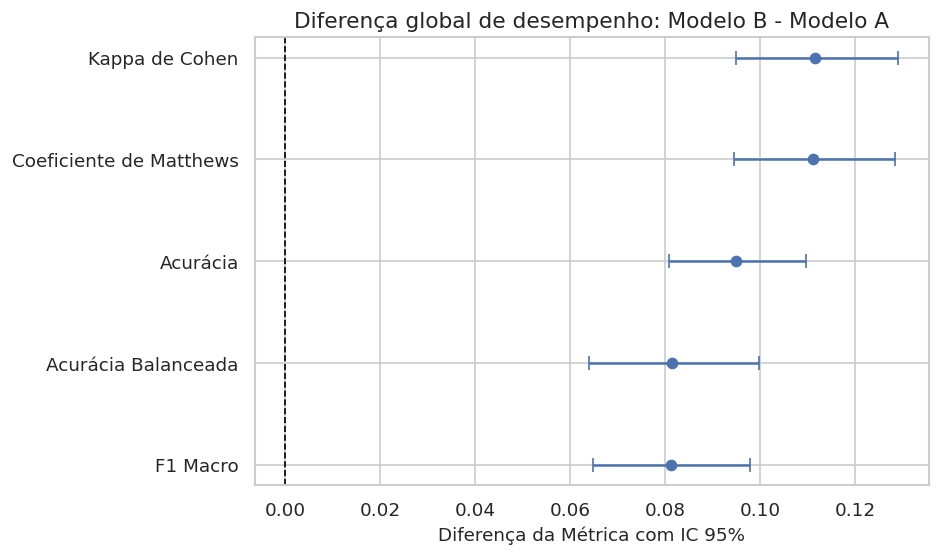

In [ ]:
metricas_principais = ["Acurácia", "Acurácia Balanceada","F1 Macro",
                    "F1 Ponderado", "Kappa de Cohen", "Coeficiente de Matthews"]

dados_plot = (tabela_global_ab.loc[tabela_global_ab["Métrica"].isin(metricas_principais)]
    .copy().sort_values("Δ(B-A)"))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(
    dados_plot["Δ(B-A)"],
    dados_plot["Métrica"],
    xerr=[
        dados_plot["Δ(B-A)"] - dados_plot["Δ IC Inf. (95%)"],
        dados_plot["Δ IC Sup. (95%)"] - dados_plot["Δ(B-A)"]
    ],
    fmt="o",
    capsize=4
)

ax.axvline(0, color="black", linewidth=1, linestyle="--")

ax.set_title("Diferença global de desempenho: Modelo B - Modelo A")
ax.set_xlabel("Diferença da Métrica com IC 95%")
ax.set_ylabel("")

save_figure(fig, fig_dir, "07_diferenca_metricas_globais_modelo_b_menos_a.png")
plt.show()

In [ ]:
def metricas_binarias_categoria(df, categoria, coluna_pred):
    real_pos = df["categoria_real"] == categoria
    pred_pos = df[coluna_pred] == categoria

    tp = int((real_pos & pred_pos).sum())
    fp = int((~real_pos & pred_pos).sum())
    fn = int((real_pos & ~pred_pos).sum())
    tn = int((~real_pos & ~pred_pos).sum())

    suporte_real = tp + fn
    suporte_predito = tp + fp

    precision = tp / suporte_predito if suporte_predito > 0 else np.nan
    recall = tp / suporte_real if suporte_real > 0 else np.nan
    f1 = 2 * precision * recall / (precision + recall) if pd.notna(precision) and pd.notna(recall) and precision + recall > 0 else np.nan

    return {"tp": tp,"fp": fp,"fn": fn,"tn": tn, "suporte_real": suporte_real,
            "suporte_predito": suporte_predito, "precision": precision,"recall": recall,"f1": f1}


def comparar_por_categoria(df, labels):
    linhas = []
    for categoria in labels:
        met_a = metricas_binarias_categoria(df, categoria, "pred_modelo_a")
        met_b = metricas_binarias_categoria(df, categoria, "pred_modelo_b")

        subset_real = df[df["categoria_real"] == categoria]
        teste_recall = executar_mcnemar(subset_real["acerto_modelo_a"], subset_real["acerto_modelo_b"])

        linhas.append({
            "Categoria": pretty_label(categoria),
            "Suporte Real": met_a["suporte_real"],
            "Suporte Predito A": met_a["suporte_predito"],
            "Suporte Predito B": met_b["suporte_predito"],
            "Precisão A": met_a["precision"],
            "Precisão B": met_b["precision"],
            "Δ Precisão (B-A)": met_b["precision"] - met_a["precision"],
            "Recall A": met_a["recall"],
            "Recall B": met_b["recall"],
            "Δ Recall (B-A)": met_b["recall"] - met_a["recall"],
            "F1 A": met_a["f1"],
            "F1 B": met_b["f1"],
            "Δ F1 (B-A)": met_b["f1"] - met_a["f1"],
            "A_acerta_B_erra_na_categoria": teste_recall["a_acerta_b_erra"],
            "B_acerta_A_erra_na_categoria": teste_recall["b_acerta_a_erra"],
            "ganho_liquido_B_na_categoria": teste_recall["ganho_liquido_b"],
            "P-valor Mcnemar Recall": teste_recall["p_valor"],
            "Método Mcnemar Recall": teste_recall["metodo"]
        })

    tabela = pd.DataFrame(linhas)
    tabela["p_valor_mcnemar_recall_ajustado_bh"] = multipletests(tabela["P-valor Mcnemar Recall"]
                                                                .fillna(1),method="fdr_bh")[1]

    return tabela.sort_values("Suporte Real", ascending=False)

In [ ]:
def bootstrap_deltas_categoria(df, labels, n_bootstrap=1000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    linhas = []

    for _ in range(n_bootstrap):
        amostra = gerar_amostra_bootstrap_estratificada(df, coluna_estrato="categoria_real", rng=rng)

        for categoria in labels:
            met_a = metricas_binarias_categoria(amostra, categoria, "pred_modelo_a")
            met_b = metricas_binarias_categoria(amostra, categoria, "pred_modelo_b")

            linhas.append({
                "Categoria": categoria,
                "Δ Precisão (B-A)": met_b["precision"] - met_a["precision"],
                "Δ Recall (B-A)": met_b["recall"] - met_a["recall"],
                "Δ F1(B-A)": met_b["f1"] - met_a["f1"]})

    boot = pd.DataFrame(linhas)
    resumo = (boot.groupby("Categoria").agg(
            delta_precision_ic95_inf=("Δ Precisão (B-A)", lambda x: x.quantile(alpha / 2)),
            delta_precision_ic95_sup=("Δ Precisão (B-A)", lambda x: x.quantile(1 - alpha / 2)),
            delta_recall_ic95_inf=("Δ Recall (B-A)", lambda x: x.quantile(alpha / 2)),
            delta_recall_ic95_sup=("Δ Recall (B-A)", lambda x: x.quantile(1 - alpha / 2)),
            delta_f1_ic95_inf=("Δ F1 (B-A)", lambda x: x.quantile(alpha / 2)),
            delta_f1_ic95_sup=("Δ F1 (B-A)", lambda x: x.quantile(1 - alpha / 2))).reset_index())

    return resumo, boot

In [59]:
tabela_categoria_ab = comparar_por_categoria(df_comp, classes)
ic_categoria_ab, bootstrap_categoria_ab = bootstrap_deltas_categoria(
    df_comp, labels=classes, n_bootstrap=n_bootstrap, alpha=alpha, seed=seed)
tabela_categoria_ab = tabela_categoria_ab.merge(ic_categoria_ab,on="Categoria",how="left")

#### Trade-Off entre Precisão e Recall

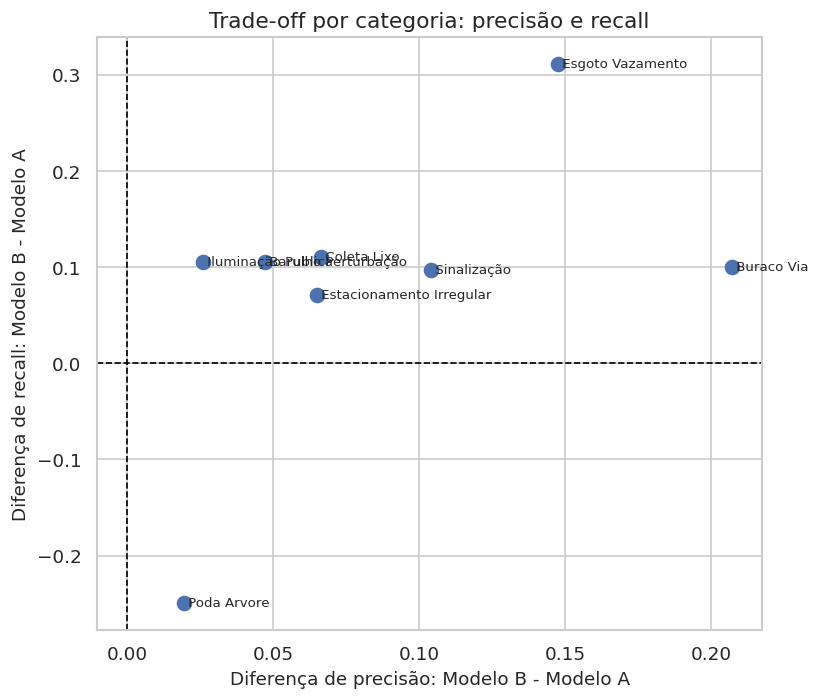

In [61]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    tabela_categoria_ab["Δ Precisão (B-A)"],
    tabela_categoria_ab["Δ Recall (B-A)"],
    s=70
)

for _, linha in tabela_categoria_ab.iterrows():
    ax.text(
        linha["Δ Precisão (B-A)"],
        linha["Δ Recall (B-A)"],
        " " + linha["Categoria"],
        fontsize=8,
        va="center"
    )

ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Trade-off por categoria: precisão e recall")
ax.set_xlabel("Diferença de precisão: Modelo B - Modelo A")
ax.set_ylabel("Diferença de recall: Modelo B - Modelo A")

save_figure(fig, fig_dir, "07_tradeoff_precision_recall_por_categoria_modelo_b_menos_a.png")
plt.show()

In [62]:
tabela_trocas_categoria = (
    df_comp
    .groupby("categoria_real")
    .agg(
        n=("id_chamado", "count"),
        ambos_acertam=("ambos_acertam", "sum"),
        ambos_erram=("ambos_erram", "sum"),
        a_acerta_b_erra=("a_acerta_b_erra", "sum"),
        b_acerta_a_erra=("b_acerta_a_erra", "sum"),
        confianca_media_a=("conf_modelo_a", "mean"),
        confianca_media_b=("conf_modelo_b", "mean")
    )
    .reset_index()
)

tabela_trocas_categoria["categoria_pt"] = tabela_trocas_categoria["categoria_real"].map(pretty_label)
tabela_trocas_categoria["ganho_liquido_b"] = tabela_trocas_categoria["b_acerta_a_erra"] - tabela_trocas_categoria["a_acerta_b_erra"]
tabela_trocas_categoria["ganho_liquido_b_pct"] = tabela_trocas_categoria["ganho_liquido_b"] / tabela_trocas_categoria["n"]

tabela_trocas_categoria = tabela_trocas_categoria.sort_values("ganho_liquido_b", ascending=False)

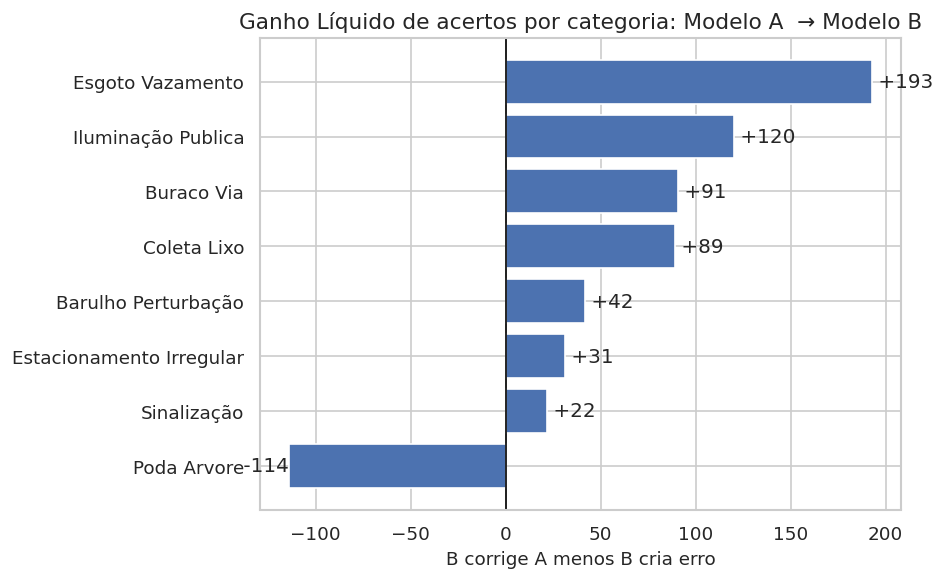

In [65]:
dados_plot = tabela_trocas_categoria.sort_values("ganho_liquido_b")

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    dados_plot["categoria_pt"],
    dados_plot["ganho_liquido_b"]
)

ax.axvline(0, color="black", linewidth=1)

ax.set_title("Ganho Líquido de acertos por categoria: Modelo A  → Modelo B")
ax.set_xlabel("B corrige A menos B cria erro")
ax.set_ylabel("")

for i, valor in enumerate(dados_plot["ganho_liquido_b"]):
    ax.text(
        valor,
        i,
        f" {valor:+.0f}",
        va="center",
        ha="left" if valor >= 0 else "right"
    )

save_figure(
    fig,
    fig_dir,
    "07_ganho_liquido_por_categoria_modelo_b_menos_a.png"
)

plt.show()

In [66]:
def comparar_acuracia_por_grupo(df, coluna_grupo, min_n=30):
    linhas = []

    for grupo, dados in df.groupby(coluna_grupo, dropna=False):
        if len(dados) < min_n:
            continue

        teste = executar_mcnemar(
            dados["acerto_modelo_a"],
            dados["acerto_modelo_b"]
        )

        acc_a = dados["acerto_modelo_a"].mean()
        acc_b = dados["acerto_modelo_b"].mean()

        linhas.append({
            "variavel": coluna_grupo,
            "grupo": grupo,
            "grupo_pt": pretty_label(grupo),
            "n": len(dados),
            "accuracy_a": acc_a,
            "accuracy_b": acc_b,
            "delta_accuracy_b_menos_a": acc_b - acc_a,
            "a_acerta_b_erra": teste["a_acerta_b_erra"],
            "b_acerta_a_erra": teste["b_acerta_a_erra"],
            "ganho_liquido_b": teste["ganho_liquido_b"],
            "p_valor_mcnemar": teste["p_valor"],
            "metodo_mcnemar": teste["metodo"]
        })

    tabela = pd.DataFrame(linhas)

    if not tabela.empty:
        tabela["p_valor_mcnemar_ajustado_bh"] = multipletests(
            tabela["p_valor_mcnemar"].fillna(1),
            method="fdr_bh"
        )[1]

    return tabela.sort_values("delta_accuracy_b_menos_a")


tabela_comp_canal = comparar_acuracia_por_grupo(df_comp, "canal", min_n=30)
tabela_comp_tamanho = comparar_acuracia_por_grupo(df_comp, "faixa_tamanho_texto", min_n=30)
tabela_comp_bairro = comparar_acuracia_por_grupo(df_comp, "bairro", min_n=50)

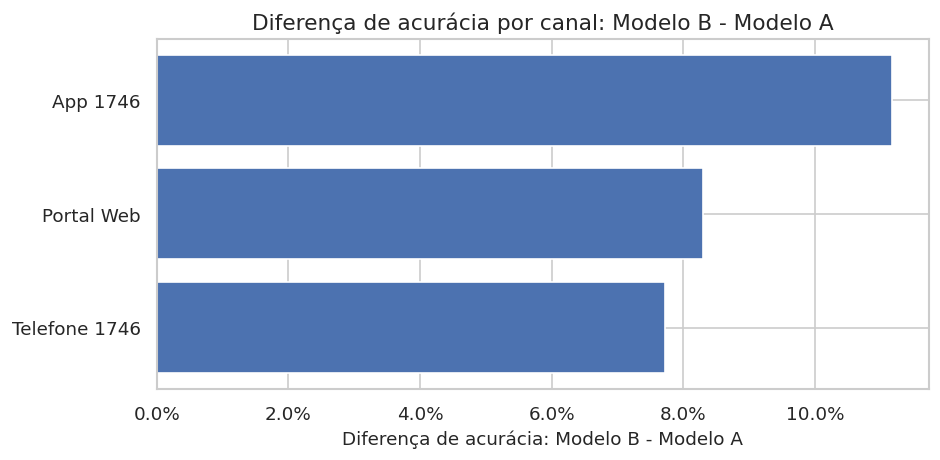

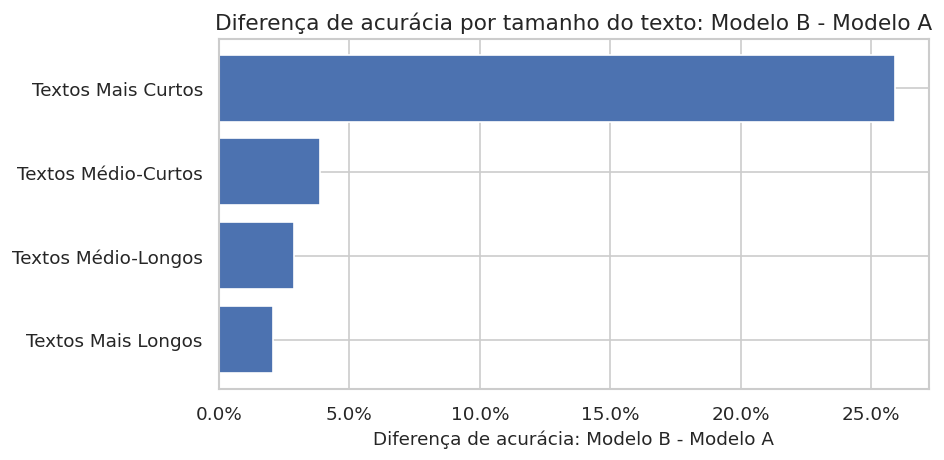

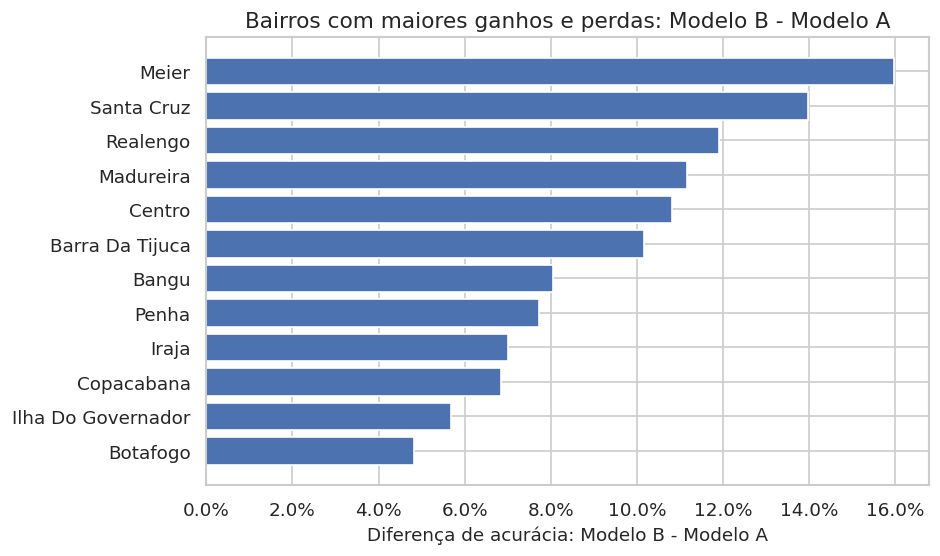

In [67]:
def plotar_delta_accuracy_grupo(tabela, titulo, nome_arquivo, top_n=None):
    dados = tabela.copy()

    if top_n is not None:
        dados = pd.concat([
            dados.head(top_n),
            dados.tail(top_n)
        ]).drop_duplicates()

    dados = dados.sort_values("delta_accuracy_b_menos_a")

    fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(dados))))

    ax.barh(
        dados["grupo_pt"],
        dados["delta_accuracy_b_menos_a"]
    )

    ax.axvline(0, color="black", linewidth=1)

    ax.set_title(titulo)
    ax.set_xlabel("Diferença de acurácia: Modelo B - Modelo A")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()


plotar_delta_accuracy_grupo(
    tabela_comp_canal,
    "Diferença de acurácia por canal: Modelo B - Modelo A",
    "07_delta_accuracy_por_canal_modelo_b_menos_a.png"
)

plotar_delta_accuracy_grupo(
    tabela_comp_tamanho,
    "Diferença de acurácia por tamanho do texto: Modelo B - Modelo A",
    "07_delta_accuracy_por_tamanho_texto_modelo_b_menos_a.png"
)

plotar_delta_accuracy_grupo(
    tabela_comp_bairro,
    "Bairros com maiores ganhos e perdas: Modelo B - Modelo A",
    "07_delta_accuracy_por_bairro_modelo_b_menos_a.png",
    top_n=6
)

In [ ]:
def classificar_tradeoff_categoria(linha):
    delta_recall = linha["Δ Recall (B-A)"]
    delta_precision = linha["Δ Precisão (B-A)"]
    delta_f1 = linha["Δ F1 (B-A)"]

    if delta_recall > 0 and delta_precision >= 0 and delta_f1 > 0:
        return "Ganho consistente"
    if delta_recall > 0 and delta_precision < 0:
        return "Ganha Recall, Perde Precisão"
    if delta_recall < 0 and delta_precision > 0:
        return "Perde Recall, Ganha Precisão"
    if delta_recall < 0 and delta_f1 < 0:
        return "Piora relevante"
    if abs(delta_recall) < 0.005 and abs(delta_f1) < 0.005:
        return "Praticamente estável"
    return "Trade-off misto"


tabela_tradeoffs_categoria = tabela_categoria_ab.copy()

tabela_tradeoffs_categoria["Diagnóstico do Tradeoff"] = tabela_tradeoffs_categoria.apply(
    classificar_tradeoff_categoria,
    axis=1
)

tabela_tradeoffs_categoria = tabela_tradeoffs_categoria[
    [   
        "Categoria",
        "Suporte Real",
        "Δ Precisão (B-A)",
        "Δ Recall (B-A)",
        "Δ F1 (B-A)",
        "Diagnóstico do Tradeoff"
    ]
].sort_values("Δ F1 (B-A)")

display(tabela_tradeoffs_categoria)

save_table(
    tabela_tradeoffs_categoria,
    tab_dir,
    "07_tradeoffs_por_categoria_modelo_a_vs_b.csv"
)

,Categoria,Suporte Real,Δ Precisão (B-A),Δ Recall (B-A),Δ F1(B-A),Diagnóstico do Tradeoff
4,Poda Arvore,458,0.019358,-0.248908,-0.147078,"Perde Recall, Ganha Precisão"
0,Iluminação Publica,1143,0.025818,0.104987,0.066602,Ganho consistente
5,Estacionamento Irregular,437,0.064899,0.070938,0.067836,Ganho consistente
6,Barulho Perturbação,400,0.047159,0.105000,0.076002,Ganho consistente
2,Coleta Lixo,806,0.066274,0.110422,0.088006,Ganho consistente
7,Sinalização,227,0.104030,0.096916,0.100802,Ganho consistente
1,Buraco Via,908,0.207060,0.100220,0.160937,Ganho consistente
3,Esgoto Vazamento,621,0.147511,0.310789,0.235887,Ganho consistente


PosixPath('../results/tables/07_tradeoffs_por_categoria_modelo_a_vs_b.csv.csv')